# Week 9 — PyTorch + Digits + DNN + DataLoader + Augmentation + Imbalance + MNIST + TensorBoard

## What we will build today

1) PyTorch basics: tensors, device (CPU/GPU), autograd, simple training loop
2) Digit classification with a Deep Neural Network (DNN / MLP)
3) Image classification workflow: Dataset + DataLoader
4) Data augmentation
5) Handling imbalanced data (Weighted loss + Weighted sampling)
6) MNIST classification end-to-end
7) Logging training with TensorBoard (loss + accuracy + sample images)

In [2]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 2.0 MB/s  0:00:36 eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 2.1 MB/s  0:00:00m 2.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.9/679.9 kB 1.8 MB/s  0:00:00m 3.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision]━━━━━━ 2/3 [torchvision]


In [8]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [9]:
import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
    x = torch.ones(1, device=device)
    print(x)
else:
    device = torch.device("cpu")

print("Using device:", device)

tensor([1.], device='mps:0')
Using device: mps


In [5]:
# 1) Tensors are like NumPy arrays but can run on GPU
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(x, x.shape, x.dtype)

# 2) Move to GPU (if available)
x = x.to(device)

# 3) Autograd: PyTorch tracks gradients if requires_grad=True
w = torch.randn(2, 1, device=device, requires_grad=True)
b = torch.zeros(1, device=device, requires_grad=True)

y_hat = x @ w + b          # linear operation
loss = (y_hat**2).mean()   # dummy loss
loss.backward()            # compute gradients

print("grad w:", w.grad)
print("grad b:", b.grad)

#PyTorch builds a computation graph automatically and loss.backward() computes gradients.

tensor([[1., 2.],
        [3., 4.]]) torch.Size([2, 2]) torch.float32
grad w: tensor([[12.1643],
        [17.1190]], device='mps:0')
grad b: tensor([4.9548], device='mps:0')


In [6]:
digits = load_digits() #Digits dataset: 8×8 grayscale images (64 features). We’ll flatten and feed into an MLP.
X = digits.data.astype(np.float32)          # (n, 64)
y = digits.target.astype(np.int64)          # (n,)

# Normalize features to [0,1] (digits data is 0..16)
X = X / 16.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

# Convert to torch tensors
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

print(X_train_t.shape, y_train_t.shape)

torch.Size([1437, 64]) torch.Size([1437])


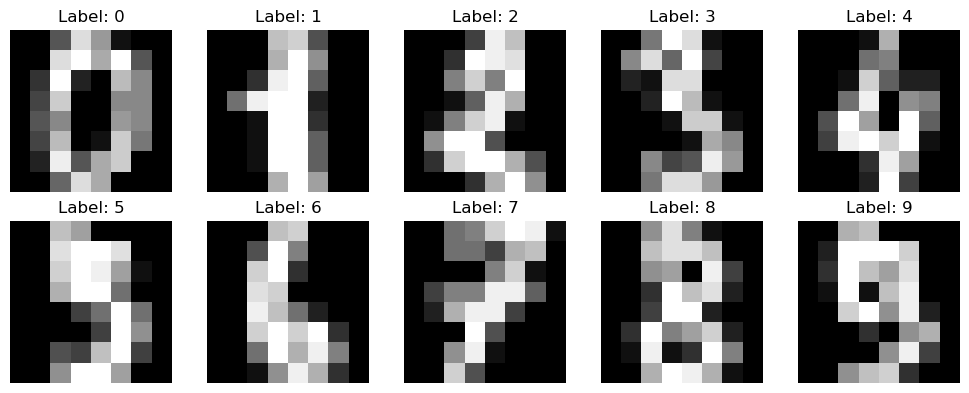

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(digits.images[i], cmap="gray")
    axes[i].set_title(f"Label: {digits.target[i]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [11]:
train_ds = TensorDataset(X_train_t, y_train_t) #creates a PyTorch Dataset object from two 
                                                #tensors: the input features X_train_t and the labels y_train_t. 
                                                #Each time the dataset is indexed (like train_ds[i]), it returns one 
                                                #training example as a pair (X_train_t[i], y_train_t[i]).

test_ds  = TensorDataset(X_test_t, y_test_t) #does the same thing for the test set, so each index returns 
                                             #(X_test_t[i], y_test_t[i]).

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

# creates a DataLoader that:
# 	•	reads data from train_ds
# 	•	groups it into mini-batches of 64 samples at a time
# 	•	uses shuffle=True to randomize the order of samples every epoch, 
#         which helps training because the model doesn’t always see data in the same order.

test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

#creates a DataLoader for evaluation that:
	# •	uses a larger batch size (256) to evaluate faster (no backprop needed)
	# •	keeps shuffle=False because test/evaluation does not require randomness; 
 #        we just want consistent evaluation over the test set.

#In short: TensorDataset packages tensors into a dataset format, and DataLoader turns that dataset into shuffled 
#mini-batches for training and orderly batches for testing.

In [15]:
# ============================================================
# PART: Define the DNN model (MLP) for Digits + training pipeline
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim


# -----------------------------
# 1) Define the MLP model class
# -----------------------------
class MLPDigits(nn.Module):
    # __init__ runs once when we create the model object
    # in_dim = number of input features (digits: 8x8 image -> 64 pixels)
    # num_classes = number of output classes (digits: 0-9 -> 10 classes)
    def __init__(self, in_dim=64, num_classes=10):
        # This initializes the parent class nn.Module
        # Without this, PyTorch will not properly track layers/parameters
        super().__init__()

        # nn.Sequential lets us stack layers in order like a pipeline:
        # input -> Linear -> ReLU -> Linear -> ReLU -> Linear -> output logits
        self.net = nn.Sequential(
            # Linear layer: maps input of size 64 -> hidden layer of size 128
            # This layer learns weights and bias
            nn.Linear(in_dim, 128),

            # ReLU activation introduces non-linearity:
            # it helps the model learn complex patterns (not just straight lines)
            nn.ReLU(),

            # Another Linear layer: 128 -> 64
            nn.Linear(128, 64),

            # Another ReLU activation
            nn.ReLU(),

            # Final Linear layer: 64 -> 10 outputs (one per class)
            # Output is called "logits" (raw scores, NOT probabilities yet)
            nn.Linear(64, num_classes)
        )

    # forward() defines how input x moves through the network
    # When we call model(x), PyTorch internally calls forward(x)
    def forward(self, x):
        # Pass x through the sequential network
        return self.net(x)


# -----------------------------
# 2) Create the model object
# -----------------------------

# Create an instance of the model class
model = MLPDigits(in_dim=64, num_classes=10)

# Move the model parameters to the selected device (CPU or GPU)
# If device is "cuda", training becomes much faster on supported machines
model = model.to(device)

# Print the model architecture so students can see layers clearly
print(model)


# ------------------------------------------------------------
# 3) Define the loss function (criterion) and optimizer
# ------------------------------------------------------------

# CrossEntropyLoss is the standard loss for multi-class classification.
# It internally applies softmax to logits and then computes negative log-likelihood.
# IMPORTANT: CrossEntropyLoss expects:
# - model output: logits of shape (batch_size, num_classes)
# - target labels: integer class ids of shape (batch_size,)
criterion = nn.CrossEntropyLoss()

# Adam optimizer updates model weights using gradients computed by backprop.
# lr = learning rate controls step size during optimization.
optimizer = optim.Adam(model.parameters(), lr=1e-3)



MLPDigits(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [16]:

# ------------------------------------------------------------
# 4) Training: one epoch function (one full pass over train data)
# ------------------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion):
    # Put model in training mode.
    # This matters for layers like Dropout/BatchNorm (even if not used here).
    model.train()

    # Track total loss across the epoch
    total_loss = 0.0

    # Track classification accuracy: correct predictions / total samples
    correct = 0
    total = 0

    # Loop over batches created by DataLoader
    for xb, yb in loader:
        # Move the batch to the same device as the model (CPU/GPU)
        xb = xb.to(device)
        yb = yb.to(device)

        # Clear old gradients (PyTorch accumulates gradients by default)
        optimizer.zero_grad()

        # Forward pass: model produces logits for each class
        logits = model(xb)

        # Compute loss between predicted logits and true class labels
        loss = criterion(logits, yb)

        # Backward pass: compute gradients of loss w.r.t. parameters
        loss.backward()

        # Update parameters using the optimizer (one step of gradient descent)
        optimizer.step()

        # Add batch loss (multiply by batch size so we can average later)
        total_loss += loss.item() * xb.size(0)

        # Convert logits to class predictions by taking argmax
        preds = logits.argmax(dim=1)

        # Count how many predictions are correct in this batch
        correct += (preds == yb).sum().item()

        # Update how many samples we processed
        total += xb.size(0)

    # Average loss over all samples
    avg_loss = total_loss / total

    # Accuracy over all samples
    acc = correct / total

    # Return both for printing/logging
    return avg_loss, acc


# ------------------------------------------------------------
# 5) Evaluation function (no gradient computation)
# ------------------------------------------------------------
@torch.no_grad()  # disables gradient tracking -> faster and uses less memory
def evaluate(model, loader, criterion):
    # Put model in evaluation mode
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    # Loop over test batches
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        # Forward pass (no backward pass)
        logits = model(xb)

        # Compute loss
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)

        # Predicted class = argmax logit
        preds = logits.argmax(dim=1)

        correct += (preds == yb).sum().item()
        total += xb.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc


# ------------------------------------------------------------
# 6) Training loop (multiple epochs)
# ------------------------------------------------------------

# Number of full passes over training data
num_epochs = 10

for epoch in range(1, num_epochs + 1):
    # Train for one epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)

    # Evaluate on test set
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    # Print progress for the students
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
    )



Epoch 01 | Train Loss: 2.2254, Train Acc: 0.3208 | Test Loss: 2.0984, Test Acc: 0.4972
Epoch 02 | Train Loss: 1.8836, Train Acc: 0.6033 | Test Loss: 1.5766, Test Acc: 0.6694
Epoch 03 | Train Loss: 1.2442, Train Acc: 0.8038 | Test Loss: 0.9188, Test Acc: 0.8250
Epoch 04 | Train Loss: 0.7218, Train Acc: 0.8622 | Test Loss: 0.5801, Test Acc: 0.8611
Epoch 05 | Train Loss: 0.4862, Train Acc: 0.8894 | Test Loss: 0.4131, Test Acc: 0.9111
Epoch 06 | Train Loss: 0.3579, Train Acc: 0.9221 | Test Loss: 0.3254, Test Acc: 0.9250
Epoch 07 | Train Loss: 0.2910, Train Acc: 0.9325 | Test Loss: 0.2781, Test Acc: 0.9194
Epoch 08 | Train Loss: 0.2453, Train Acc: 0.9360 | Test Loss: 0.2438, Test Acc: 0.9250
Epoch 09 | Train Loss: 0.2115, Train Acc: 0.9534 | Test Loss: 0.2049, Test Acc: 0.9417
Epoch 10 | Train Loss: 0.1832, Train Acc: 0.9534 | Test Loss: 0.1844, Test Acc: 0.9500


In [17]:

# ------------------------------------------------------------
# 7) Predict on a single sample (demo)
# ------------------------------------------------------------

# Take one batch from test loader
xb, yb = next(iter(test_loader))

# Take the first sample from the batch
x_one = xb[0].to(device)        # shape: (64,)
y_true = yb[0].item()           # true label as Python int

# Model expects shape (batch_size, features), so add batch dimension
x_one = x_one.unsqueeze(0)      # shape becomes (1, 64)

# Forward pass -> logits for 10 classes
logits = model(x_one)

# Convert logits to predicted class
y_pred = logits.argmax(dim=1).item()

print("True label:", y_true)
print("Predicted :", y_pred)

True label: 5
Predicted : 5


In [10]:
# ============================================================
# PART C: Fashion-MNIST Image Classification
# Focus: Dataset, DataLoader, Data Augmentation (in-depth)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt
import numpy as np

In [11]:
# ============================================================
# Block 1) What is a Dataset vs DataLoader?
# ============================================================
# Dataset:
#   - stores the data
#   - implements __len__() = how many samples
#   - implements __getitem__(idx) = returns one sample (image, label)
#
# DataLoader:
#   - takes a Dataset and creates mini-batches
#   - handles shuffling
#   - can load data faster using multiple workers
#   - returns batches: (batch_images, batch_labels)
#
# In deep learning, we rarely train with the full dataset at once.
# We train using mini-batches for faster and more stable training.

In [12]:
# ============================================================
# Block 2) Define transforms (Data Augmentation)
# ============================================================
# Data augmentation = artificially create "new" training examples
# by applying random transformations to training images.
# This helps the model generalize better (reduces overfitting).
#
# IMPORTANT RULE:
# - Apply augmentation ONLY on training data.
# - Do NOT augment test data (test must represent real unseen data).

# Train transforms: include random augmentations
train_transform = T.Compose([
    # Random rotation (e.g., +/- 10 degrees)
    # Helps model handle small rotation changes in real-world data
    T.RandomRotation(degrees=10),

    # Random affine transform: translation + small scaling
    # translate=(0.1,0.1) means move image up to 10% in x/y direction
    # scale=(0.9,1.1) means zoom in/out slightly
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),

    # Convert PIL image -> torch tensor in range [0, 1]
    T.ToTensor(),

    # Normalize using dataset mean/std (common practice)
    # For Fashion-MNIST, these values are widely used in examples
    T.Normalize((0.2860,), (0.3530,))
])

# Test transforms: NO random augmentation
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.2860,), (0.3530,))
])

In [13]:
# ============================================================
# Block 3) Load Fashion-MNIST dataset
# ============================================================
# Fashion-MNIST has:
# - 60,000 training images
# - 10,000 test images
# - grayscale images of size 28x28
# - 10 classes (T-shirt/top, Trouser, etc.)

from torchvision.datasets import FashionMNIST

train_ds = FashionMNIST(root="./data", train=True, download=True, transform=train_transform)
test_ds  = FashionMNIST(root="./data", train=False, download=True, transform=test_transform)

print("Train size:", len(train_ds))
print("Test size :", len(test_ds))

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

Train size: 60000
Test size : 10000


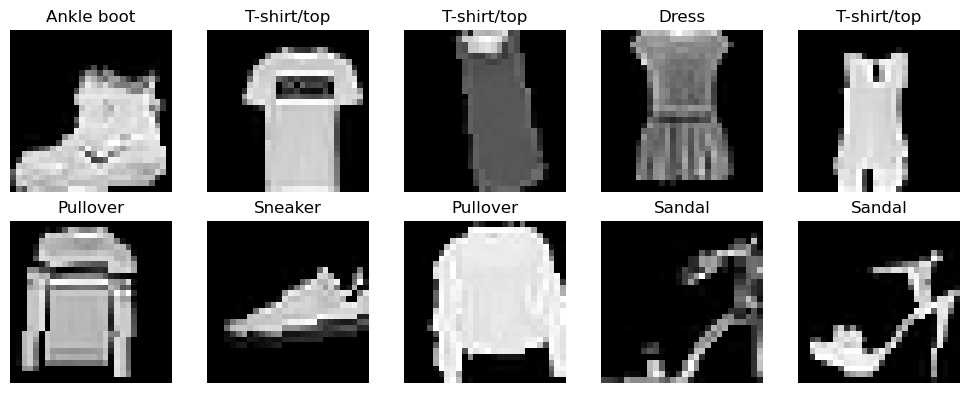

In [14]:
# ============================================================
# Block 4) Visualize augmented training samples
# ============================================================
# Because train_transform includes randomness, the *same index*
# can look different each time you call train_ds[idx].

# Helper: unnormalize for display (reverse Normalize)
def unnormalize(img_tensor, mean=0.2860, std=0.3530):
    # img_tensor shape: (1, 28, 28)
    return img_tensor * std + mean

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    img, label = train_ds[i]  # augmented image (because train_ds uses train_transform)
    img_disp = unnormalize(img).squeeze(0)  # remove channel dim for imshow

    axes[i].imshow(img_disp, cmap="gray")
    axes[i].set_title(class_names[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Block 5) Create DataLoaders (in-depth)
# ============================================================
# Key DataLoader parameters:
#
# batch_size:
#   - how many samples per batch
#   - common values: 32, 64, 128
#
# shuffle:
#   - training: True (randomize order each epoch)
#   - testing : False (keep deterministic order)
#
# num_workers:
#   - number of background processes used to load data
#   - speeds up loading on CPU-heavy pipelines
#   - on Windows: often must be 0
#
# pin_memory:
#   - helps speed CPU->GPU transfer (useful if using GPU)
#
# drop_last:
#   - training: True sometimes (keeps batch size consistent)
#   - testing: False (we want all samples)

batch_size = 64

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,      # set 0 if it causes issues on your system
    pin_memory=True,    # helpful if GPU
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=256,     # bigger batch for faster evaluation
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Check one batch
xb, yb = next(iter(train_loader))
print("Batch X shape:", xb.shape)  # (batch_size, 1, 28, 28)
print("Batch y shape:", yb.shape)  # (batch_size,)

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Batch X shape: torch.Size([64, 1, 28, 28])
Batch y shape: torch.Size([64])


In [16]:
# ============================================================
# Block 6) Define a simple CNN for Fashion-MNIST
# ============================================================
# CNN is better than MLP for images because it uses spatial structure.
# Input shape: (B, 1, 28, 28)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Feature extractor (convolutions)
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # -> (B,16,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # -> (B,16,14,14)

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # -> (B,32,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2)                              # -> (B,32,7,7)
        )

        # Classifier (fully connected layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # -> (B, 32*7*7)
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)                  # -> (B,10) logits
        )

    def forward(self, x):
        x = self.features(x)         # extract features
        x = self.classifier(x)       # classify
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCrossEntropyLoss(nn.Module):
    """
    Custom implementation of Cross Entropy for multi-class classification.

    Inputs:
      - logits: shape (B, C)  (raw model outputs, NOT softmaxed)
      - targets: shape (B,)   (integer class labels 0..C-1)

    What it does:
      1) computes log probabilities using log_softmax(logits)
      2) picks the log-prob of the correct class for each sample
      3) returns negative average (or sum) of those values

    Optional:
      - weight: tensor of shape (C,) to give different importance to classes
      - reduction: "mean" or "sum" or "none"
    """
    def __init__(self, weight=None, reduction="mean"):
        super().__init__()
        self.register_buffer("weight", weight if weight is not None else None)
        self.reduction = reduction

    def forward(self, logits, targets):
        # logits: (B, C)
        # targets: (B,)
        log_probs = F.log_softmax(logits, dim=1)   # (B, C)

        # Select log-probability of the correct class for each sample:
        # gather needs targets as (B,1)
        correct_log_probs = log_probs.gather(1, targets.view(-1, 1)).squeeze(1)  # (B,)

        # Negative log likelihood
        loss = -correct_log_probs  # (B,)

        # Apply class weights if provided
        if self.weight is not None:
            # weight per sample = weight[target_class]
            sample_weights = self.weight[targets]     # (B,)
            loss = loss * sample_weights

        # Reduction
        if self.reduction == "mean":
            # If weights exist, mean should be weighted mean for fairness
            if self.weight is not None:
                return loss.sum() / (sample_weights.sum() + 1e-12)
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        elif self.reduction == "none":
            return loss
        else:
            raise ValueError("reduction must be one of: 'mean', 'sum', 'none'")
            
# ============================================================
# Block 7) Loss function + optimizer
# ============================================================
# CrossEntropyLoss for multi-class classification
# It expects:
# - logits (raw outputs) shape: (B, num_classes)
# - y labels shape: (B,) containing integers 0..9

# criterion = nn.CrossEntropyLoss()
criterion = CustomCrossEntropyLoss(reduction="mean")

# Adam optimizer adjusts learning rate per parameter
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [18]:
# ============================================================
# Block 8) Training and evaluation loops (compact but clear)
# ============================================================

def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()            # clear old gradients
        logits = model(xb)               # forward pass
        loss = criterion(logits, yb)     # compute loss
        loss.backward()                  # backprop gradients
        optimizer.step()                 # update weights

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    return total_loss / total, correct / total

In [19]:
# ============================================================
# Block 9) Train the CNN for a few epochs
# ============================================================
epochs = 5

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch 01 | Train Loss: 0.6799, Train Acc: 0.7433 | Test Loss: 0.4430, Test Acc: 0.8377
Epoch 02 | Train Loss: 0.4883, Train Acc: 0.8148 | Test Loss: 0.4026, Test Acc: 0.8447
Epoch 03 | Train Loss: 0.4298, Train Acc: 0.8375 | Test Loss: 0.3419, Test Acc: 0.8755
Epoch 04 | Train Loss: 0.3938, Train Acc: 0.8517 | Test Loss: 0.3213, Test Acc: 0.8834
Epoch 05 | Train Loss: 0.3634, Train Acc: 0.8641 | Test Loss: 0.3199, Test Acc: 0.8810


In [20]:
# ============================================================
# Block 10) Predict on one test image (single example demo)
# ============================================================
# This helps students connect output logits -> predicted class.

xb, yb = next(iter(test_loader))
x_one = xb[0].to(device)          # (1,28,28)
y_true = yb[0].item()

# Model expects a batch dimension: (B,1,28,28)
x_one = x_one.unsqueeze(0)

logits = model(x_one)
pred_class = logits.argmax(dim=1).item()

print("True label     :", class_names[y_true])
print("Predicted label:", class_names[pred_class])

True label     : Ankle boot
Predicted label: Ankle boot


# TensorBoard (Quick Concept)

TensorBoard is a tool to **track training live**.
Instead of printing only numbers, it plots curves like:
- training loss vs epoch
- test accuracy vs epoch

It also lets you log:
- sample images
- model predictions
- model graph (optional)

This helps you quickly see:
- is the model improving?
- is it overfitting? (train improves but test gets worse)
- are there training bugs? (loss not decreasing)

In [32]:
!pip install tensorboard

  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 3.6 MB/s  0:00:03a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [tensorboard] 3/4 [tensorboard]


In [21]:
from torch.utils.tensorboard import SummaryWriter
import time

# Create a unique run folder each time (so logs don't overwrite)
run_name = f"fashionmnist_{time.strftime('%Y%m%d-%H%M%S')}"
log_dir = f"./runs/{run_name}"

writer = SummaryWriter(log_dir=log_dir)
print("TensorBoard logs will be saved to:", log_dir)

TensorBoard logs will be saved to: ./runs/fashionmnist_20260419-110601


In [22]:
# Log scalar values (these become line plots in TensorBoard)
writer.add_scalar("Loss/train", train_loss, epoch)
writer.add_scalar("Loss/test", test_loss, epoch)

writer.add_scalar("Accuracy/train", train_acc, epoch)
writer.add_scalar("Accuracy/test", test_acc, epoch)

In [23]:
# Log a small batch of images
xb_vis, yb_vis = next(iter(test_loader))  # a batch from test set
writer.add_images("Images/test_samples", xb_vis[:16], epoch)  # log 16 images

In [24]:
# Log predicted labels vs true labels for a few images
model.eval()
with torch.no_grad():
    xb_vis = xb_vis.to(device)
    logits = model(xb_vis)
    preds = logits.argmax(dim=1).cpu()

# Convert first 16 predictions to readable text
pred_text = "\n".join([
    f"i={i}: pred={class_names[int(preds[i])]}, true={class_names[int(yb_vis[i])]}"
    for i in range(16)
])

writer.add_text("Predictions/sample_batch", pred_text, epoch)

In [25]:
writer.close()

In [26]:
from torch.utils.tensorboard import SummaryWriter
import time

run_name = f"fashionmnist_{time.strftime('%Y%m%d-%H%M%S')}"
writer = SummaryWriter(log_dir=f"./runs/{run_name}")

epochs = 5
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    print(f"Epoch {epoch:02d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
          f"Test Loss {test_loss:.4f} Acc {test_acc:.4f}")

    # --- TensorBoard scalar logs ---
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)

    # --- TensorBoard image logs (16 test images) ---
    xb_vis, yb_vis = next(iter(test_loader))
    writer.add_images("Images/test_samples", xb_vis[:16], epoch)

writer.close()
print("Done. Run: tensorboard --logdir=./runs")

Epoch 01 | Train Loss 0.3477 Acc 0.8704 | Test Loss 0.2855 Acc 0.8967
Epoch 02 | Train Loss 0.3336 Acc 0.8763 | Test Loss 0.2852 Acc 0.8969
Epoch 03 | Train Loss 0.3226 Acc 0.8795 | Test Loss 0.2867 Acc 0.8986
Epoch 04 | Train Loss 0.3106 Acc 0.8843 | Test Loss 0.2761 Acc 0.9017
Epoch 05 | Train Loss 0.3036 Acc 0.8882 | Test Loss 0.2610 Acc 0.9097
Done. Run: tensorboard --logdir=./runs
